In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [ ]:

x, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

<Axes: >

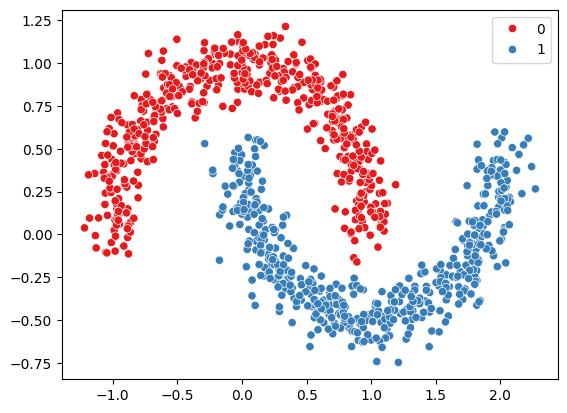

In [3]:
import seaborn as sns
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y, palette='Set1')

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [5]:
from keras.models import Sequential
from keras.layers import Dense


In [ ]:
model = Sequential([
    Dense(10, activation='relu', input_shape=(2,), kernel_initializer='he_normal'),  #here we can assign the he weight initialization to the each layer of the model. The he weight initialization is a good choice for layers with ReLU activation functions, as it helps to prevent the vanishing gradient problem and allows for faster convergence during training. 
    Dense(10, activation='relu', kernel_initializer='he_normal'),
    Dense(1, activation='sigmoid', kernel_initializer='he_normal')
])

f:\Python\Deep-Learning-and-Computer-vision\deepenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4922 - loss: 0.9236 - val_accuracy: 0.5312 - val_loss: 0.8203
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5188 - loss: 0.8149 - val_accuracy: 0.6562 - val_loss: 0.7310
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6297 - loss: 0.7225 - val_accuracy: 0.6500 - val_loss: 0.6562
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6516 - loss: 0.6448 - val_accuracy: 0.6562 - val_loss: 0.5923
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6672 - loss: 0.5781 - val_accuracy: 0.6687 - val_loss: 0.5387
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6891 - loss: 0.5219 - val_accuracy: 0.7125 - val_loss: 0.4933
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7391 - loss: 0.4760 - val_accuracy: 0.7437 - val_loss: 0.4545
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7594 - loss: 0.4365 - val_accuracy: 0.7688 - 

<Axes: >

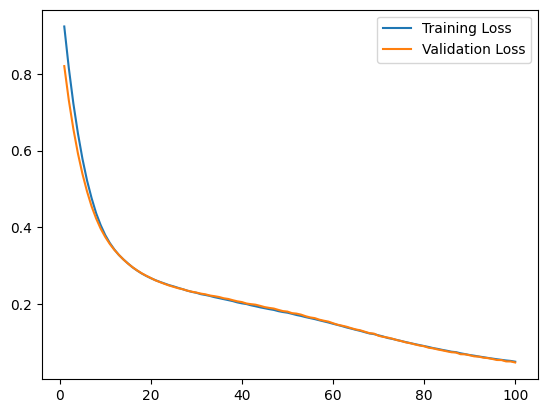

In [9]:
sns.lineplot(x=range(1, 101), y=history.history['loss'], label='Training Loss')
sns.lineplot(x=range(1, 101), y=history.history['val_loss'], label='Validation Loss')